In [ ]:
# =========================================
# REGRESIÓN LINEAL - ÓXIDO NITROSO
# Autor: Juan José Velasco
# Notebook: Regresion Simple
# =========================================

In [ ]:
# Modelos de Regresión Lineal Simple

#En este notebook se construyen modelos de regresión lineal simple para evaluar la relación entre las emisiones de óxido nitroso (NOx) y las variables ambientales de humedad, temperatura y presión barométrica.

#Los modelos serán comparados utilizando el coeficiente de determinación R² con el propósito de identificar cuál variable presenta mayor capacidad explicativa sobre la variabilidad observada en las emisiones de NOx.

In [2]:
#Importacion de librerías
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from scipy import stats

sns.set(style="whitegrid")

In [14]:
# Cargar el dataset
df = pd.read_excel("../data/oxido nitroso.xls")


# Renombrar columnas con nombres limpios para la regresión
df.columns = [
    "NOx",        # Óxido nitroso
    "Humidity",     # Humedad relativa
    "Temp",        # Temperatura
    "Pressure"   # Presión atmosférica
]

df.head()

,NOx,Humidity,Temp,Pressure
0,0.90,72.4,76.3,29.18
1,0.91,41.6,70.3,29.35
2,0.96,34.3,77.1,29.24
3,0.89,35.1,68.0,29.27
4,1.00,10.7,79.0,29.78


In [15]:
# Modelo de regresión lineal: NOx en función de Humidity
modelo_h = smf.ols("NOx ~ Humidity", data=df).fit()

# Resumen del modelo
print(modelo_h.summary())


                            OLS Regression Results                            
Dep. Variable:                    NOx   R-squared:                       0.770
Model:                            OLS   Adj. R-squared:                  0.757
Method:                 Least Squares   F-statistic:                     60.18
Date:                Mon, 11 May 2026   Prob (F-statistic):           3.79e-07
Time:                        18:44:18   Log-Likelihood:                 30.010
No. Observations:                  20   AIC:                            -56.02
Df Residuals:                      18   BIC:                            -54.03
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.1144      0.022     49.660      0.0

In [16]:
# Modelo de regresión lineal: NOx en función de Temp
modelo_t = smf.ols("NOx ~ Temp", data=df).fit()

print(modelo_t.summary())

                            OLS Regression Results                            
Dep. Variable:                    NOx   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                 -0.021
Method:                 Least Squares   F-statistic:                    0.6080
Date:                Mon, 11 May 2026   Prob (F-statistic):              0.446
Time:                        18:48:55   Log-Likelihood:                 15.655
No. Observations:                  20   AIC:                            -27.31
Df Residuals:                      18   BIC:                            -25.32
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.2160      0.315      3.856      0.0

In [17]:
# Modelo de regresión lineal: NOx en función de Pressure
modelo_p = smf.ols("NOx ~ Pressure", data=df).fit()

print(modelo_p.summary())

                            OLS Regression Results                            
Dep. Variable:                    NOx   R-squared:                       0.599
Model:                            OLS   Adj. R-squared:                  0.577
Method:                 Least Squares   F-statistic:                     26.90
Date:                Mon, 11 May 2026   Prob (F-statistic):           6.21e-05
Time:                        18:49:49   Log-Likelihood:                 24.463
No. Observations:                  20   AIC:                            -44.93
Df Residuals:                      18   BIC:                            -42.93
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -12.5581      2.609     -4.814      0.0

In [18]:
r2 = pd.DataFrame({
    "Modelo": ["Humidity", "Temp", "Pressure"],
    "R2": [
        modelo_h.rsquared,
        modelo_t.rsquared,
        modelo_p.rsquared
    ]
})

r2.sort_values(by="R2", ascending=False)

,Modelo,R2
0,Humidity,0.769767
2,Pressure,0.599089
1,Temp,0.032676


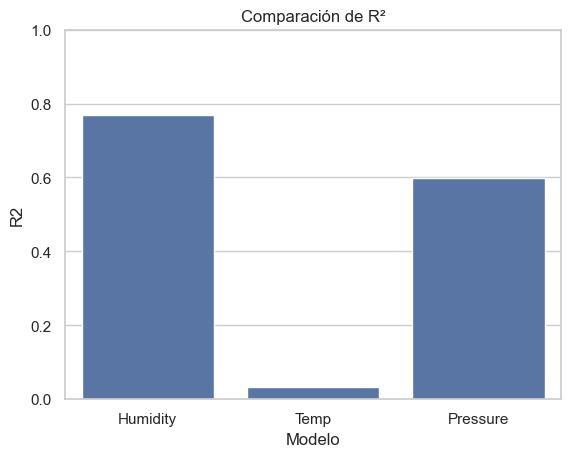

In [19]:
sns.barplot(data=r2, x="Modelo", y="R2")

plt.title("Comparación de R²")
plt.ylim(0,1)

plt.show()

In [ ]:
# El mejor modelo de regresión lineal simple para explicar la variabilidad en las emisiones 
# de NOx es el que utiliza Humidity como variable independiente, 
# con un R² de aproximadamente 0.769, indicando que el 76.9% de la variabilidad en NOx puede
# ser explicada por la humedad relativa.

In [ ]:
# Ecuación del modelo de regresión lineal simple con Humidity
intercepto = modelo_h.params["Intercept"]
pendiente = modelo_h.params["Humidity"]

print("Ecuación:")
print(f"NOx = {intercepto:.4f} + ({pendiente:.4f})*Humidity")


Ecuación:
NOx = 1.1144 + (-0.0033)*Humidity


In [ ]:
# por cada incremento de una unidad en Humidity, se espera una disminución de aproximadamente 0.0033 ppm promedio
# en las emisiones de NOx, manteniendo constantes las demás variables.

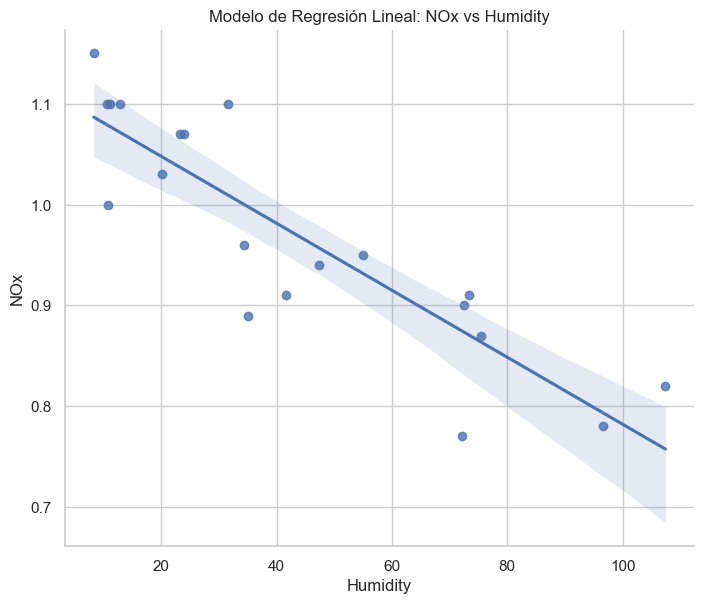

In [ ]:
#Grafico de dispersión con línea de regresión para el modelo mejor modelo, Humidity vs NOx
sns.lmplot(
    data=df,
    x="Humidity",
    y="NOx",
    height=6,
    aspect=1.2
)

plt.title("Modelo de Regresión Lineal: NOx vs Humidity")

plt.show()

In [ ]:
#Hipotesis para el modelo de regresión lineal simple con Humidity:
# Efecto Inverso de la Humedad

#H₀: β₁ ≥ 0

#La humedad no tiene efecto inverso sobre NOx.

#H₁: β₁ < 0

#La humedad tiene un efecto inverso sobre NOx.

In [3]:
parametros = modelo_h.params
pvalue = modelo_h.pvalues["Humidity"]

print(f"Parámetros del modelo: \n{parametros}")
print(f"P-valor para Humidity: {pvalue:.4f}")

NameError: name 'modelo_h' is not defined

In [ ]:
# Conclusiones

# El modelo basado en Humidity (%) presentó el mayor coeficiente de determinación R², por lo que fue seleccionado como el mejor modelo de regresión lineal simple.
# El modelo indica una relación lineal negativa entre la humedad y las emisiones de NOx.
# La pendiente estimada sugiere que incrementos en la humedad generan disminuciones promedio en los niveles de emisión de óxido nitroso.
# La prueba F del modelo presentó un valor-p inferior a 0.05, indicando que el modelo es estadísticamente significativo para explicar la variabilidad de NOx.
# La evidencia estadística respalda la afirmación de que la humedad tiene un efecto inverso sobre las emisiones de óxido nitroso.